# Analysis of Hospital Inpatient Discharges

### Import the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(color_codes=True)

### Reading training data

In [2]:
df = pd.read_csv('Hospital_Inpatient_Discharges__SPARCS_De-Identified___2021_20240715.csv')
df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\2644447478.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Hospital_Inpatient_Discharges__SPARCS_De-Identified___2021_20240715.csv')


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,70 or Older,104,M,Other Race,Spanish/Hispanic,...,Major,Extreme,Medical,Medicare,Medicaid,NaN,NaN,Y,320922.43,60241.34
1,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,White,Not Span/Hispanic,...,Moderate,Minor,Medical,Private Health Insurance,NaN,NaN,NaN,Y,61665.22,9180.69
2,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,F,Other Race,Spanish/Hispanic,...,Minor,Minor,Surgical,Medicaid,NaN,NaN,NaN,N,42705.34,11366.50
3,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,70 or Older,104,M,Other Race,Spanish/Hispanic,...,Major,Major,Medical,Medicare,Medicaid,NaN,NaN,Y,72700.17,12111.75
4,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicare,Medicaid,NaN,NaN,Y,55562.51,8339.72


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2135260 entries, 0 to 2135259
Data columns (total 33 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Hospital Service Area                object 
 1   Hospital County                      object 
 2   Operating Certificate Number         float64
 3   Permanent Facility Id                float64
 4   Facility Name                        object 
 5   Age Group                            object 
 6   Zip Code - 3 digits                  object 
 7   Gender                               object 
 8   Race                                 object 
 9   Ethnicity                            object 
 10  Length of Stay                       object 
 11  Type of Admission                    object 
 12  Patient Disposition                  object 
 13  Discharge Year                       int64  
 14  CCSR Diagnosis Code                  object 
 15  CCSR Diagnosis Description      

### Transforming the Length of Stay Attribute to Numeric Format

In [4]:
df['Length of Stay'] = pd.to_numeric(df['Length of Stay'], errors='coerce')

### Dropping Irrelavant Column

In [5]:
columns_to_remove = ['Operating Certificate Number', 'Permanent Facility Id', 'CCSR Diagnosis Code', 'CCSR Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code']

In [6]:
df = df.drop(columns=columns_to_remove)
df.shape

(2135260, 26)

In [7]:
df['Discharge Year'].value_counts()

Discharge Year
2021    2135260
Name: count, dtype: int64

In [8]:
pd.set_option('display.max_rows', None)

In [9]:
df['APR DRG Description'].value_counts()

APR DRG Description
NEONATE BIRTH WEIGHT > 2499 GRAMS, NORMAL NEWBORN OR NEONATE WITH OTHER PROBLEM                           174868
VAGINAL DELIVERY                                                                                          126001
SEPTICEMIA AND DISSEMINATED INFECTIONS                                                                    124160
MAJOR RESPIRATORY INFECTIONS AND INFLAMMATIONS                                                             87978
CESAREAN SECTION WITHOUT STERILIZATION                                                                     61366
HEART FAILURE                                                                                              57839
SCHIZOPHRENIA                                                                                              31193
KIDNEY AND URINARY TRACT INFECTIONS                                                                        25909
CVA AND PRECEREBRAL OCCLUSION WITH INFARCTION                               

### Filtered patients by 'APR DRG Description' to identify knee orthoplasty cases.

In [10]:
filtered_df = df[df['CCSR Procedure Description'].isin([
    
    'KNEE ARTHROPLASTY'])]

In [11]:
filtered_df.shape

(22214, 26)

### Analyzed 'APR Medical Surgical Description' to determine if primarily surgical procedures.

In [12]:
filtered_df['APR Medical Surgical Description'].value_counts()

APR Medical Surgical Description
Surgical    22191
Medical        23
Name: count, dtype: int64

### Examined 'CCSR Diagnosis Description' to verify osteoarthritis as primary indication for knee orthoplasty.

In [13]:
filtered_df['CCSR Diagnosis Description'].value_counts()

CCSR Diagnosis Description
Osteoarthritis                                                                 19153
Complication of internal orthopedic device or implant, initial encounter        2365
Other aftercare encounter                                                        131
Fracture of the lower limb (except hip), initial encounter                       112
Rheumatoid arthritis and related disease                                          48
Other specified joint disorders                                                   47
Complication of other surgical or medical care, injury, initial encounter         39
Traumatic arthropathy                                                             35
Aseptic necrosis and osteonecrosis                                                24
Nervous system pain and pain syndromes                                            18
Complication of internal orthopedic device or implant, subsequent encounter       17
Fracture of lower limb (except hip), s

### Checking for missing values

In [14]:
missing_val = filtered_df.count()/len(filtered_df)
missing_val = (1-missing_val)*100
missing_val.sort_values(ascending=False)

Birth Weight                           100.000000
Payment Typology 3                      86.630053
Payment Typology 2                      42.743315
Zip Code - 3 digits                      2.156298
Hospital Service Area                    0.067525
Hospital County                          0.067525
APR DRG Description                      0.000000
Total Charges                            0.000000
Emergency Department Indicator           0.000000
Payment Typology 1                       0.000000
APR Medical Surgical Description         0.000000
APR Risk of Mortality                    0.000000
APR Severity of Illness Description      0.000000
APR MDC Description                      0.000000
CCSR Procedure Description               0.000000
CCSR Diagnosis Description               0.000000
Discharge Year                           0.000000
Patient Disposition                      0.000000
Type of Admission                        0.000000
Length of Stay                           0.000000


- Payment Typology 1, 2, and 3 are assumed to represent primary, secondary, and tertiary modes of payment.
- Significant missing data is present before filtering, and these columns are removed after filtering for knee arthroplasty as there were still some more missing data.
- The Birth Weight column is also removed due to 100% missing values post-filtering.

### Removing features more than 40 percent missing values

In [15]:
columns_to_remove = ['Birth Weight', 'Payment Typology 2', 'Payment Typology 3']

In [16]:
# Drop the irrelevant columns
filtered_df = filtered_df.drop(columns=columns_to_remove)
filtered_df.shape

(22214, 23)

In [17]:
filtered_df['Payment Typology 1'].value_counts()

Payment Typology 1
Medicare                     13033
Private Health Insurance      3265
Blue Cross/Blue Shield        2546
Medicaid                      2029
Miscellaneous/Other            987
Managed Care, Unspecified      139
Self-Pay                       128
Federal/State/Local/VA          84
Department of Corrections        3
Name: count, dtype: int64

### Derived a new feature 'Payer Type' based on 'Payment Typology 1' attribute.

In [18]:
government_insurance = ["Medicare", "Medicaid", "Federal/State/Local/VA", "Department of Corrections"]
private_payers = ["Private Health Insurance", "Blue Cross/Blue Shield", "Miscellaneous/Other", "Managed Care, Unspecified", "Self-Pay"]

def classify_payer_type(payer):
    if payer in government_insurance:
        return 'Government Insurance'
    elif payer in private_payers:
        return 'Private Payers'

In [19]:
filtered_df['Payer Type'] = filtered_df['Payment Typology 1'].apply(classify_payer_type)

In [20]:
filtered_df.head()

,Hospital Service Area,Hospital County,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,Length of Stay,Type of Admission,...,APR DRG Description,APR MDC Description,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Emergency Department Indicator,Total Charges,Total Costs,Payer Type
458,Hudson Valley,Rockland,Montefiore Nyack,50 to 69,109,F,Black/African American,Not Span/Hispanic,2.0,Elective,...,ELECTIVE KNEE JOINT REPLACEMENT,DISEASES AND DISORDERS OF THE MUSCULOSKELETAL ...,Moderate,Minor,Surgical,Private Health Insurance,N,87958.45,21556.02,Private Payers
482,New York City,Manhattan,Metropolitan Hospital Center,30 to 49,100,F,Black/African American,Not Span/Hispanic,1.0,Elective,...,ELECTIVE KNEE JOINT REPLACEMENT,DISEASES AND DISORDERS OF THE MUSCULOSKELETAL ...,Minor,Minor,Surgical,Miscellaneous/Other,N,26904.19,24267.98,Private Payers
990,New York City,Bronx,Lincoln Medical & Mental Health Center,50 to 69,104,F,Other Race,Spanish/Hispanic,3.0,Elective,...,ELECTIVE KNEE JOINT REPLACEMENT,DISEASES AND DISORDERS OF THE MUSCULOSKELETAL ...,Minor,Minor,Surgical,Private Health Insurance,N,52057.56,33271.29,Private Payers
1909,New York City,Kings,Kings County Hospital Center,50 to 69,112,F,Black/African American,Unknown,1.0,Elective,...,ELECTIVE KNEE JOINT REPLACEMENT,DISEASES AND DISORDERS OF THE MUSCULOSKELETAL ...,Minor,Minor,Surgical,Medicaid,N,50294.07,36305.58,Government Insurance
2678,Hudson Valley,Rockland,Montefiore Nyack,70 or Older,109,M,White,Not Span/Hispanic,3.0,Elective,...,ELECTIVE KNEE JOINT REPLACEMENT,DISEASES AND DISORDERS OF THE MUSCULOSKELETAL ...,Moderate,Moderate,Surgical,Medicare,N,93899.27,22649.56,Government Insurance


### Univariate Analysis

(array([0, 1]),
 [Text(0, 0, 'Private Payers'), Text(1, 0, 'Government Insurance')])

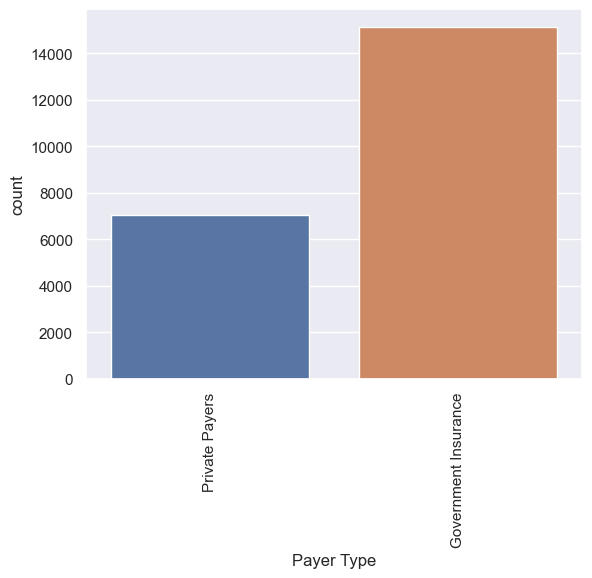

In [21]:
sns.countplot(x= 'Payer Type', data = filtered_df)
plt.xticks(rotation=90)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
 [Text(0, 0, '109'),
  Text(1, 0, '100'),
  Text(2, 0, '104'),
  Text(3, 0, '112'),
  Text(4, 0, '117'),
  Text(5, 0, 'OOS'),
  Text(6, 0, '115'),
  Text(7, 0, '148'),
  Text(8, 0, '111'),
  Text(9, 0, '107'),
  Text(10, 0, '125'),
  Text(11, 0, '105'),
  Text(12, 0, '108'),
  Text(13, 0, '113'),
  Text(14, 0, '106'),
  Text(15, 0, '103'),
  Text(16, 0, '119'),
  Text(17, 0, '124'),
  Text(18, 0, '118'),
  Text(19, 0, '110'),
  Text(20, 0, '127'),
  Text(21, 0, '116'),
  Text(22, 0, '138'),
  Text(23, 0, '114'),
  Text(24, 0, '146'),
  Text(25, 0, '145'),
  Text(26, 0, '144'),
  Text(27, 0, '101'),
  Text(28, 0, '131'),
  Text(29, 0, '134'),
  Text(30, 0, '133'),
  Text(31, 0, '122'),
  Text(32, 0, '126'),
  Text(33, 0, '140'),
  Text(34, 0, '142'),
  Text(35, 0, 

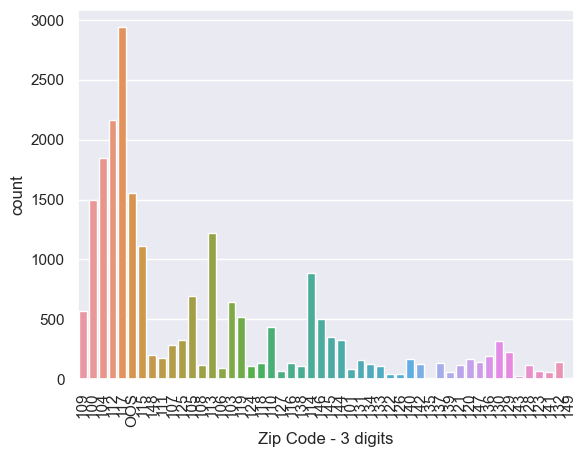

In [22]:
sns.countplot(x= 'Zip Code - 3 digits', data = filtered_df)
plt.xticks(rotation=90)

In [23]:
mode_value = filtered_df['Zip Code - 3 digits'].mode()[0]
mode_value

'117'

In [24]:
filtered_df['Zip Code - 3 digits'].fillna(mode_value, inplace=True)

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Hudson Valley'),
  Text(1, 0, 'New York City'),
  Text(2, 0, 'Capital/Adirond'),
  Text(3, 0, 'Long Island'),
  Text(4, 0, 'Finger Lakes'),
  Text(5, 0, 'Central NY'),
  Text(6, 0, 'Western NY'),
  Text(7, 0, 'Southern Tier')])

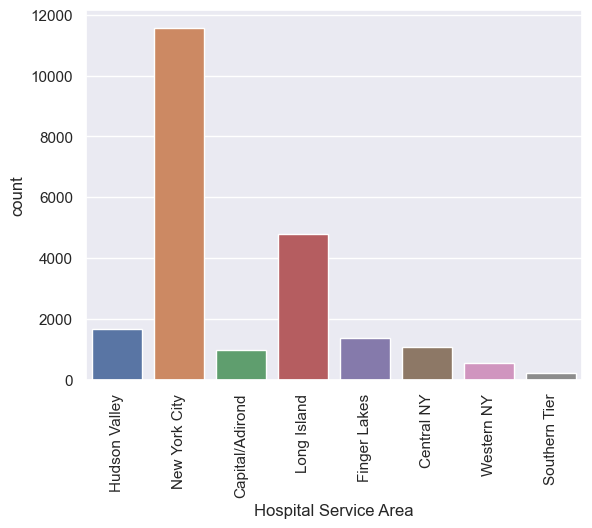

In [25]:
sns.countplot(x= 'Hospital Service Area', data = filtered_df)
plt.xticks(rotation=90)

### From the graph, we can conclude that most of the knee arthroplasty patients are from New York City, New York.

In [26]:
mode_value = filtered_df['Hospital Service Area'].mode()[0]
mode_value

'New York City'

In [27]:
filtered_df['Hospital Service Area'].fillna(mode_value, inplace=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]),
 [Text(0, 0, 'Rockland'),
  Text(1, 0, 'Manhattan'),
  Text(2, 0, 'Bronx'),
  Text(3, 0, 'Kings'),
  Text(4, 0, 'Westchester'),
  Text(5, 0, 'Otsego'),
  Text(6, 0, 'Nassau'),
  Text(7, 0, 'Monroe'),
  Text(8, 0, 'Cayuga'),
  Text(9, 0, 'Madison'),
  Text(10, 0, 'Orange'),
  Text(11, 0, 'Ontario'),
  Text(12, 0, 'Queens'),
  Text(13, 0, 'Allegany'),
  Text(14, 0, 'Erie'),
  Text(15, 0, 'Oneida'),
  Text(16, 0, 'Broome'),
  Text(17, 0, 'Suffolk'),
  Text(18, 0, 'Albany'),
  Text(19, 0, 'Richmond'),
  Text(20, 0, 'Chautauqua'),
  Text(21, 0, 'Oswego'),
  Text(22, 0, 'Putnam'),
  Text(23, 0, 'Jefferson'),
  Text(24, 0, 'Dutchess'),
  Text(25, 0, 'Livingston'),
  Text(26, 0, 'Steuben'),
  Text(27, 0, 'Tompkins'),
  Text(28, 0, 'Franklin'),
  Text(29, 0, 'Onondaga'),
  Tex

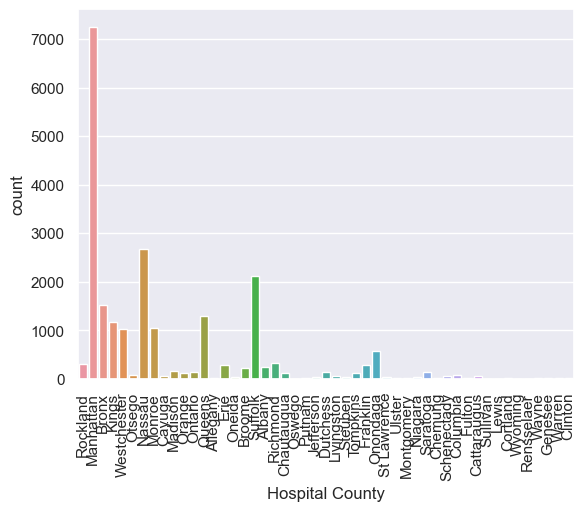

In [28]:
sns.countplot(x= 'Hospital County', data = filtered_df)
plt.xticks(rotation=90)

In [29]:
mode_value = filtered_df['Hospital County'].mode()[0]
mode_value

'Manhattan'

In [30]:
filtered_df['Hospital County'].fillna(mode_value, inplace=True)

In [31]:
missing_val = filtered_df.count()/len(filtered_df)
missing_val = (1-missing_val)*100
missing_val.sort_values(ascending=False)

Hospital Service Area                  0.0
Hospital County                        0.0
Total Costs                            0.0
Total Charges                          0.0
Emergency Department Indicator         0.0
Payment Typology 1                     0.0
APR Medical Surgical Description       0.0
APR Risk of Mortality                  0.0
APR Severity of Illness Description    0.0
APR MDC Description                    0.0
APR DRG Description                    0.0
CCSR Procedure Description             0.0
CCSR Diagnosis Description             0.0
Discharge Year                         0.0
Patient Disposition                    0.0
Type of Admission                      0.0
Length of Stay                         0.0
Ethnicity                              0.0
Race                                   0.0
Gender                                 0.0
Zip Code - 3 digits                    0.0
Age Group                              0.0
Facility Name                          0.0
Payer Type 

In [32]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22214 entries, 458 to 2135222
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Hospital Service Area                22214 non-null  object 
 1   Hospital County                      22214 non-null  object 
 2   Facility Name                        22214 non-null  object 
 3   Age Group                            22214 non-null  object 
 4   Zip Code - 3 digits                  22214 non-null  object 
 5   Gender                               22214 non-null  object 
 6   Race                                 22214 non-null  object 
 7   Ethnicity                            22214 non-null  object 
 8   Length of Stay                       22214 non-null  float64
 9   Type of Admission                    22214 non-null  object 
 10  Patient Disposition                  22214 non-null  object 
 11  Discharge Year               

In [33]:
filtered_df.describe()

,Length of Stay,Discharge Year,Total Charges,Total Costs
count,22214.000000,22214.0,2.221400e+04,22214.000000
mean,2.619024,2021.0,8.544753e+04,26422.039200
std,2.862795,0.0,6.229480e+04,17253.136282
min,1.000000,2021.0,5.340000e+02,80.000000
25%,1.000000,2021.0,4.965284e+04,14988.062500
50%,2.000000,2021.0,7.200189e+04,22985.455000
75%,3.000000,2021.0,1.007659e+05,32680.095000
max,70.000000,2021.0,1.801302e+06,673660.790000


### Dropped 'Discharge date' feature because all values were identical.

In [34]:
filtered_df = filtered_df.drop(columns=['Discharge Year'])
filtered_df.shape

(22214, 23)

In [35]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22214 entries, 458 to 2135222
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Hospital Service Area                22214 non-null  object 
 1   Hospital County                      22214 non-null  object 
 2   Facility Name                        22214 non-null  object 
 3   Age Group                            22214 non-null  object 
 4   Zip Code - 3 digits                  22214 non-null  object 
 5   Gender                               22214 non-null  object 
 6   Race                                 22214 non-null  object 
 7   Ethnicity                            22214 non-null  object 
 8   Length of Stay                       22214 non-null  float64
 9   Type of Admission                    22214 non-null  object 
 10  Patient Disposition                  22214 non-null  object 
 11  CCSR Diagnosis Description   

C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\663122886.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(filtered_df['Length of Stay'])


<Axes: xlabel='Length of Stay', ylabel='Density'>

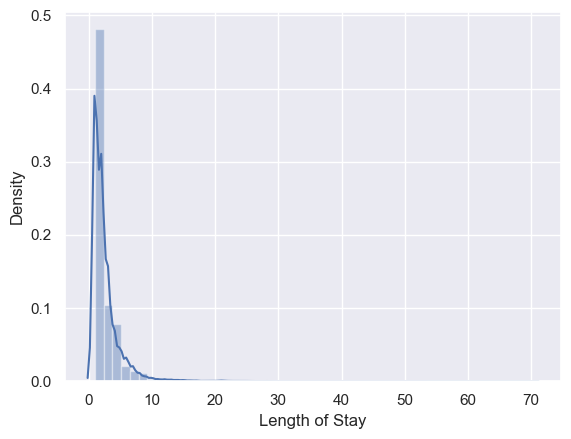

In [36]:
sns.distplot(filtered_df['Length of Stay'])

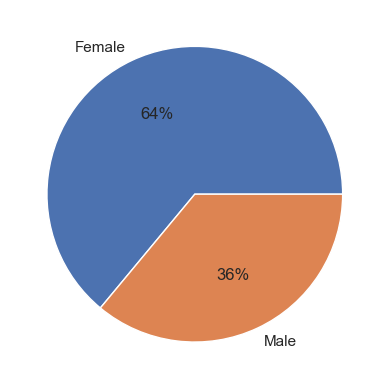

In [37]:
plt.pie(filtered_df['Gender'].value_counts(normalize=True)*100, labels=['Female', 'Male'], autopct='%1.f%%')
plt.show()

### Females represent a higher proportion of knee arthroplasty patients compared to males.

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Black/African American'),
  Text(1, 0, 'Other Race'),
  Text(2, 0, 'White'),
  Text(3, 0, 'Multi-racial')])

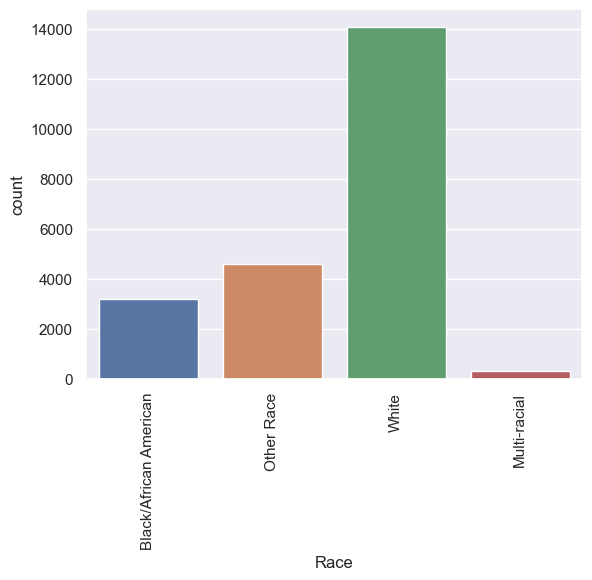

In [38]:
sns.countplot(x= 'Race', data = filtered_df)
plt.xticks(rotation=90)

### Most of the knee arthroplasty patients identified as being of White race.

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Not Span/Hispanic'),
  Text(1, 0, 'Spanish/Hispanic'),
  Text(2, 0, 'Unknown'),
  Text(3, 0, 'Multi-ethnic')])

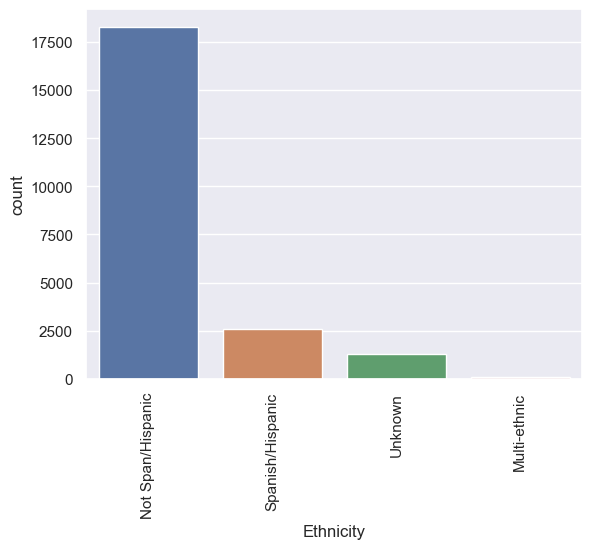

In [39]:
sns.countplot(x= 'Ethnicity', data = filtered_df)
plt.xticks(rotation=90)

### Most of the knee arthroplasty patients identified as White, with a significant number not being of Hispanic or Latino ethnicity.

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '50 to 69'),
  Text(1, 0, '30 to 49'),
  Text(2, 0, '70 or Older'),
  Text(3, 0, '18 to 29'),
  Text(4, 0, '0 to 17')])

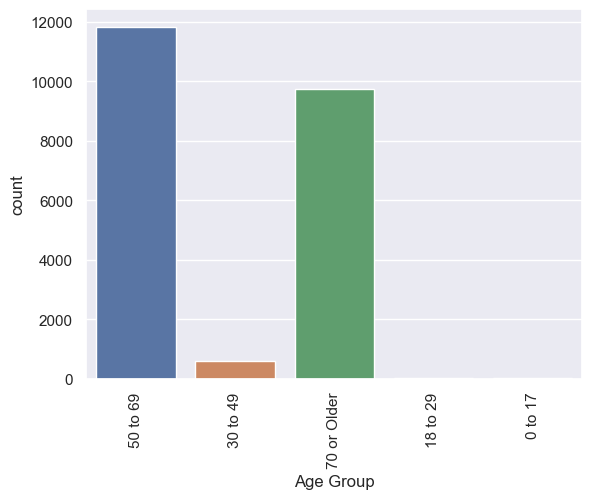

In [40]:
sns.countplot(x= 'Age Group', data = filtered_df)
plt.xticks(rotation=90)

### Most knee arthroplasty patients are over the age of 50.

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Elective'),
  Text(1, 0, 'Urgent'),
  Text(2, 0, 'Emergency'),
  Text(3, 0, 'Not Available'),
  Text(4, 0, 'Trauma')])

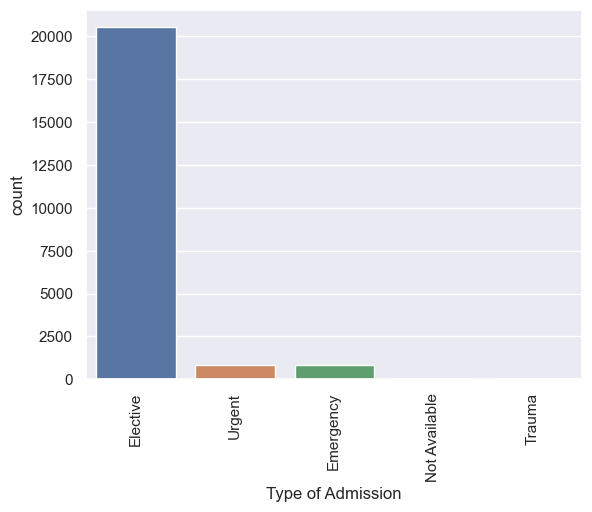

In [41]:
sns.countplot(x= 'Type of Admission', data = filtered_df)
plt.xticks(rotation=90)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'Home w/ Home Health Services'),
  Text(1, 0, 'Home or Self Care'),
  Text(2, 0, 'Skilled Nursing Home'),
  Text(3, 0, 'Inpatient Rehabilitation Facility'),
  Text(4, 0, 'Hosp Basd Medicare Approved Swing Bed'),
  Text(5, 0, 'Short-term Hospital'),
  Text(6, 0, 'Left Against Medical Advice'),
  Text(7, 0, 'Court/Law Enforcement'),
  Text(8, 0, "Cancer Center or Children's Hospital"),
  Text(9, 0, 'Another Type Not Listed'),
  Text(10, 0, 'Expired'),
  Text(11, 0, 'Medicare Cert Long Term Care Hospital'),
  Text(12, 0, 'Facility w/ Custodial/Supportive Care'),
  Text(13, 0, 'Hospice - Home'),
  Text(14, 0, 'Medicaid Cert Nursing Facility'),
  Text(15, 0, 'Federal Health Care Facility')])

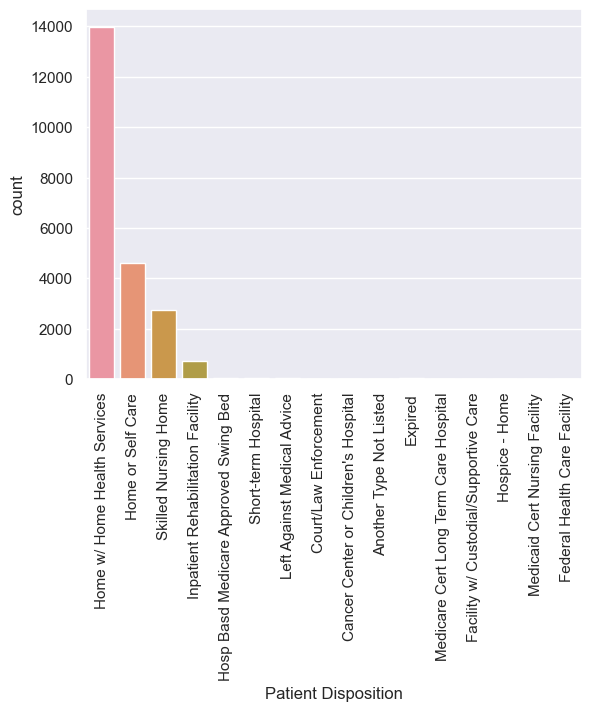

In [42]:
sns.countplot(x= 'Patient Disposition', data = filtered_df)
plt.xticks(rotation=90)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25]),
 [Text(0, 0, 'ELECTIVE KNEE JOINT REPLACEMENT'),
  Text(1, 0, 'NON-ELECTIVE OR COMPLEX KNEE JOINT REPLACEMENT'),
  Text(2, 0, 'KNEE AND LOWER LEG PROCEDURES EXCEPT FOOT'),
  Text(3, 0, 'EXTENSIVE O.R. PROCEDURE UNRELATED TO PRINCIPAL DIAGNOSIS'),
  Text(4, 0, 'MALFUNCTION, REACTION, COMPLICATION OF ORTHOPEDIC DEVICE OR PROCEDURE'),
  Text(5, 0, 'ELECTIVE HIP JOINT REPLACEMENT'),
  Text(6, 0, 'OTHER MUSCULOSKELETAL SYSTEM AND CONNECTIVE TISSUE PROCEDURES'),
  Text(7, 0, 'EXTENSIVE O.R. PROCEDURES FOR OTHER COMPLICATIONS OF TREATMENT'),
  Text(8, 0, 'PROCEDURE WITH DIAGNOSIS OF REHABILITATION, AFTERCARE OR OTHER CONTACT WITH HEALTH SERVICES'),
  Text(9, 0, 'POST-OPERATIVE, POST-TRAUMA, OTHER DEVICE INFECTIONS WITH O.R. PROCEDURE'),
  Text(10, 0, 'FOOT AND TOE PROCEDURES'),
  Text(11, 0, 'TENDON, MUSCLE AND OTHER SOFT TISSUE PROCEDURES'),
  Text(12, 0, 'AMPUTATION OF L

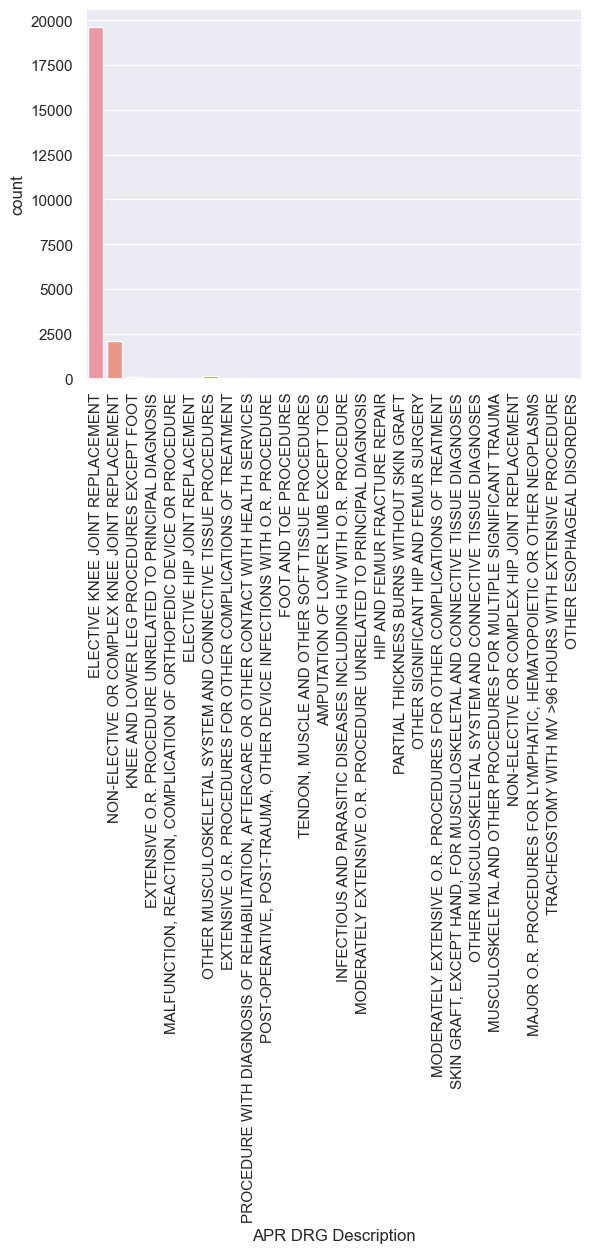

In [43]:
sns.countplot(x= 'APR DRG Description', data = filtered_df)
plt.xticks(rotation=90)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 [Text(0, 0, 'DISEASES AND DISORDERS OF THE MUSCULOSKELETAL SYSTEM AND CONNECTIVE TISSUE'),
  Text(1, 0, 'DISEASES AND DISORDERS OF THE CIRCULATORY SYSTEM'),
  Text(2, 0, 'INJURIES, POISONINGS AND TOXIC EFFECTS OF DRUGS'),
  Text(3, 0, 'FACTORS INFLUENCING HEALTH STATUS AND OTHER CONTACTS WITH HEALTH SERVICES'),
  Text(4, 0, 'INFECTIOUS AND PARASITIC DISEASES (SYSTEMIC OR UNSPECIFIED SITES)'),
  Text(5, 0, 'DISEASES AND DISORDERS OF THE DIGESTIVE SYSTEM'),
  Text(6, 0, 'DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM'),
  Text(7, 0, 'DISEASES AND DISORDERS OF THE SKIN, SUBCUTANEOUS TISSUE AND BREAST'),
  Text(8, 0, 'ALCOHOL/DRUG USE AND ALCOHOL/DRUG INDUCED ORGANIC MENTAL DISORDERS'),
  Text(9, 0, 'BURNS'),
  Text(10, 0, 'DISEASES AND DISORDERS OF THE KIDNEY AND URINARY TRACT'),
  Text(11, 0, 'DISEASES AND DISORDERS OF THE BLOOD AND BLOOD FORMING ORGANS AND IMMUNOLOGICAL DISORDERS'),
  Text(12, 0, 'ENDOCRINE

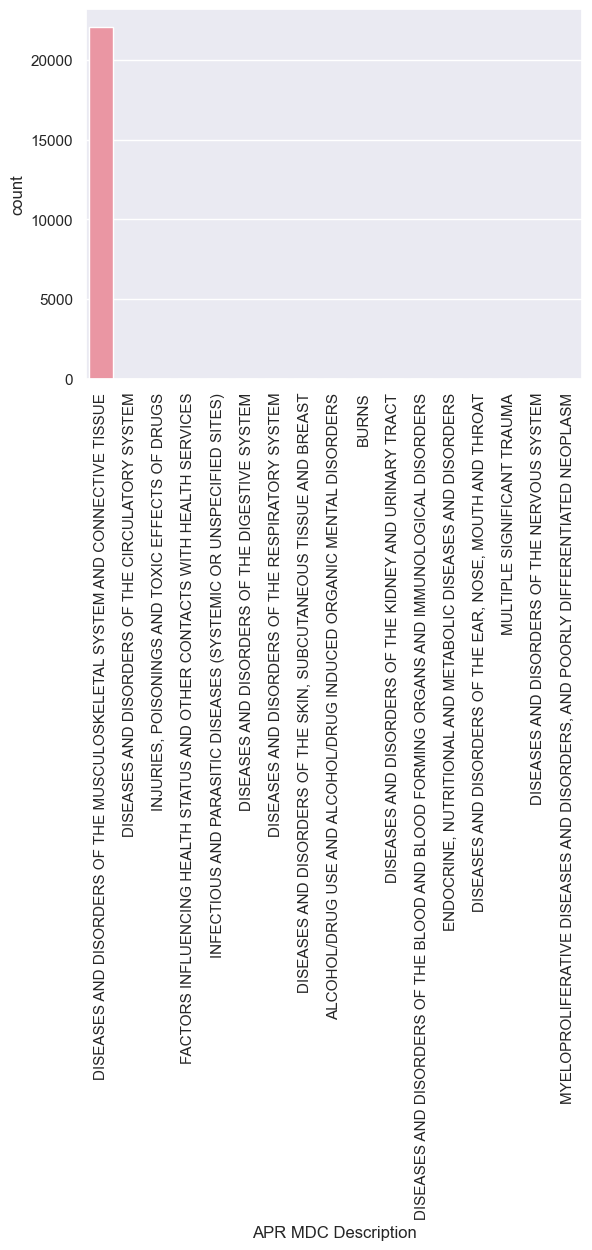

In [44]:
sns.countplot(x= 'APR MDC Description', data = filtered_df)
plt.xticks(rotation=90)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Moderate'),
  Text(1, 0, 'Minor'),
  Text(2, 0, 'Major'),
  Text(3, 0, 'Extreme')])

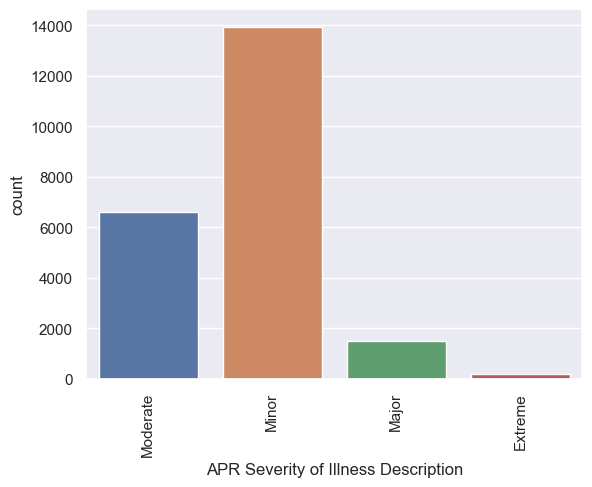

In [45]:
sns.countplot(x= 'APR Severity of Illness Description', data = filtered_df)
plt.xticks(rotation=90)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Minor'),
  Text(1, 0, 'Moderate'),
  Text(2, 0, 'Major'),
  Text(3, 0, 'Extreme')])

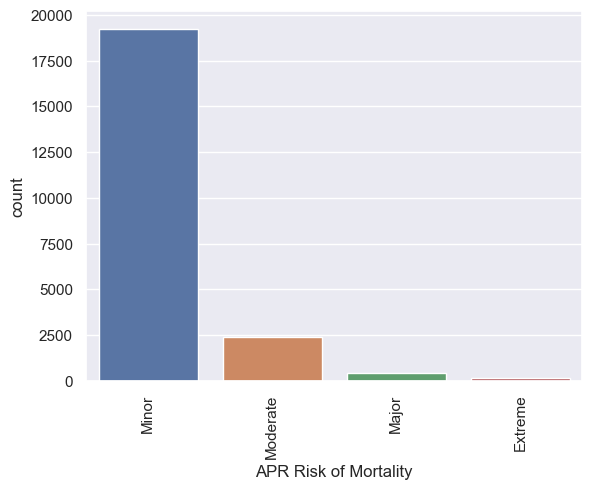

In [46]:
sns.countplot(x= 'APR Risk of Mortality', data = filtered_df)
plt.xticks(rotation=90)

(array([0, 1]), [Text(0, 0, 'Surgical'), Text(1, 0, 'Medical')])

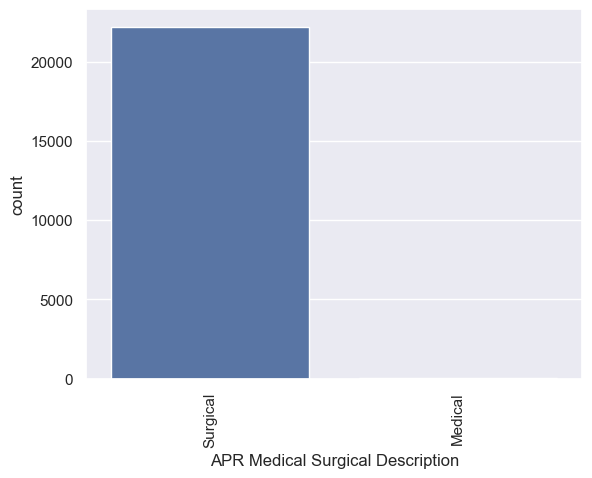

In [47]:
sns.countplot(x= 'APR Medical Surgical Description', data = filtered_df)
plt.xticks(rotation=90)

In [48]:
filtered_df['APR Medical Surgical Description'].value_counts()

APR Medical Surgical Description
Surgical    22191
Medical        23
Name: count, dtype: int64

(array([0, 1]), [Text(0, 0, 'N'), Text(1, 0, 'Y')])

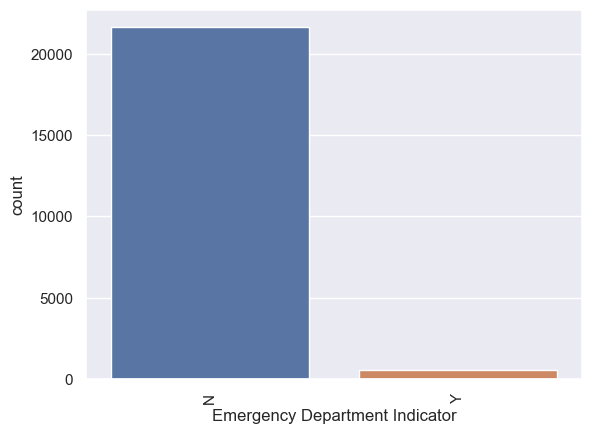

In [49]:
sns.countplot(x= 'Emergency Department Indicator', data = filtered_df)
plt.xticks(rotation=90)

### Data Distribution of all Numerical Attributes

C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\663122886.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(filtered_df['Length of Stay'])


<Axes: xlabel='Length of Stay', ylabel='Density'>

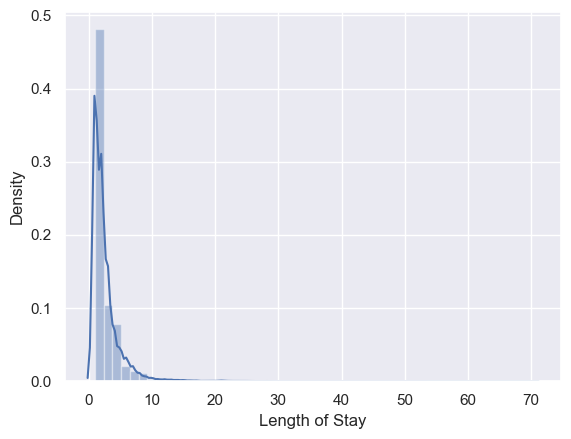

In [50]:
sns.distplot(filtered_df['Length of Stay'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\311332040.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(filtered_df['Total Charges'])


<Axes: xlabel='Total Charges', ylabel='Density'>

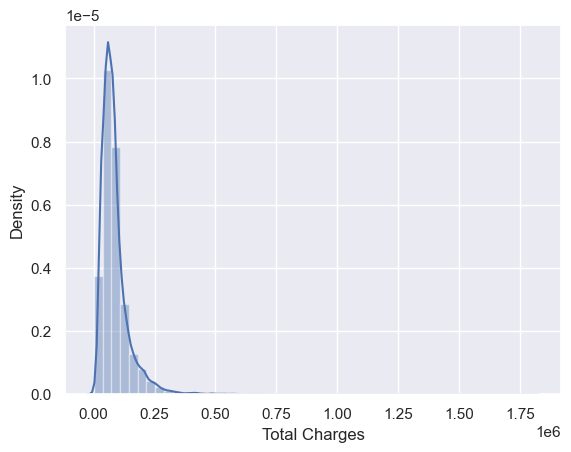

In [51]:
sns.distplot(filtered_df['Total Charges'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\3353104101.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(filtered_df['Total Costs'])


<Axes: xlabel='Total Costs', ylabel='Density'>

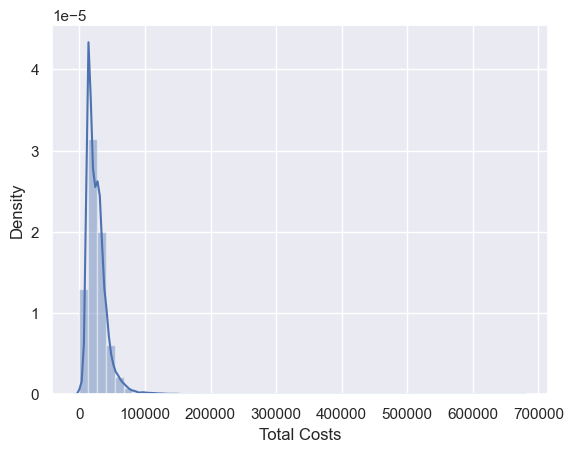

In [52]:
sns.distplot(filtered_df['Total Costs'])

In [53]:
Num_df = filtered_df.select_dtypes(include=["int64","float64"])
Num_df.head()

,Length of Stay,Total Charges,Total Costs
458,2.0,87958.45,21556.02
482,1.0,26904.19,24267.98
990,3.0,52057.56,33271.29
1909,1.0,50294.07,36305.58
2678,3.0,93899.27,22649.56


### Bivariate Analysis

<Axes: >

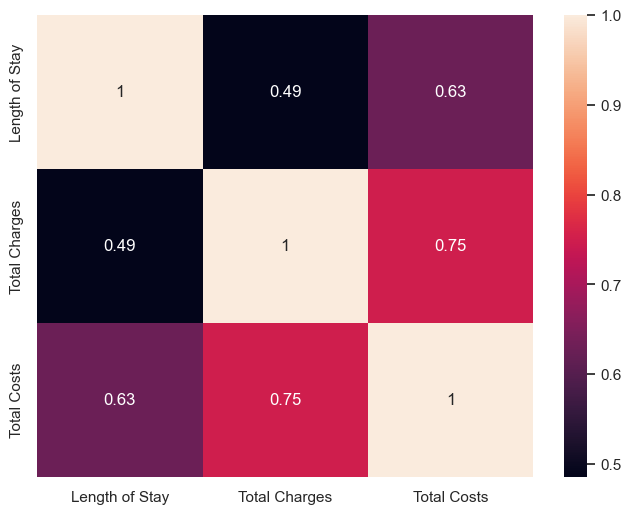

In [54]:
corrmat = Num_df.corr()
plt.subplots(figsize=(8, 6))
sns.heatmap(corrmat, annot=True)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


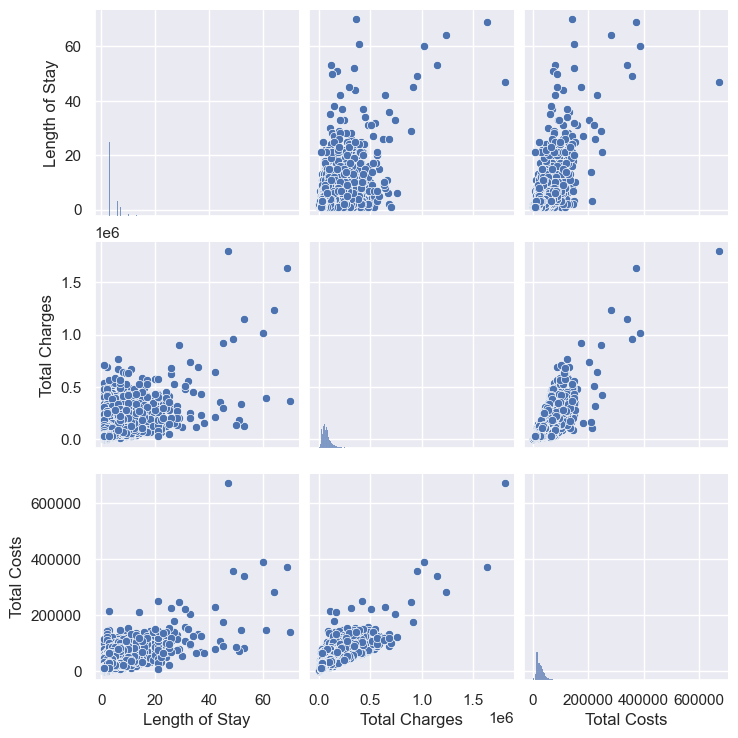

In [55]:
sns.pairplot(Num_df, size = 2.5)
plt.show()

## 1. Describe cost and hospital length of stay (LOS), by payer type (Payment Typology)

In [56]:
cost_description = filtered_df.groupby('Payment Typology 1')['Total Costs'].describe()
los_description = filtered_df.groupby('Payment Typology 1')['Length of Stay'].describe()

print("Cost Description by Payer Type:")
print(cost_description)

print("\nLength of Stay Description by Payer Type:")
print(los_description)

Cost Description by Payer Type:
                             count          mean           std       min  \
Payment Typology 1                                                         
Blue Cross/Blue Shield      2546.0  24010.498708  14883.863284     80.00   
Department of Corrections      3.0  26844.666667  11395.412493  15732.93   
Federal/State/Local/VA        84.0  21431.529048  13659.551226   3120.04   
Managed Care, Unspecified    139.0  30197.312158  19162.306250   2222.61   
Medicaid                    2029.0  28857.410044  23758.867517    189.47   
Medicare                   13033.0  26605.603418  16866.579095     80.00   
Miscellaneous/Other          987.0  23052.211651  13674.372873   1827.85   
Private Health Insurance    3265.0  26839.344830  15949.535831    206.67   
Self-Pay                     128.0  31599.469922  23234.389802   8994.28   

                                  25%        50%         75%        max  
Payment Typology 1                                       

C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\2678717097.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Payment Typology 1', y='Total Costs', data=filtered_df, estimator='mean', ci=None, palette='viridis', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\2678717097.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Payment Typology 1', y='Length of Stay', data=filtered_df, estimator='mean', ci=None, palette='viridis', ax=axes[1])


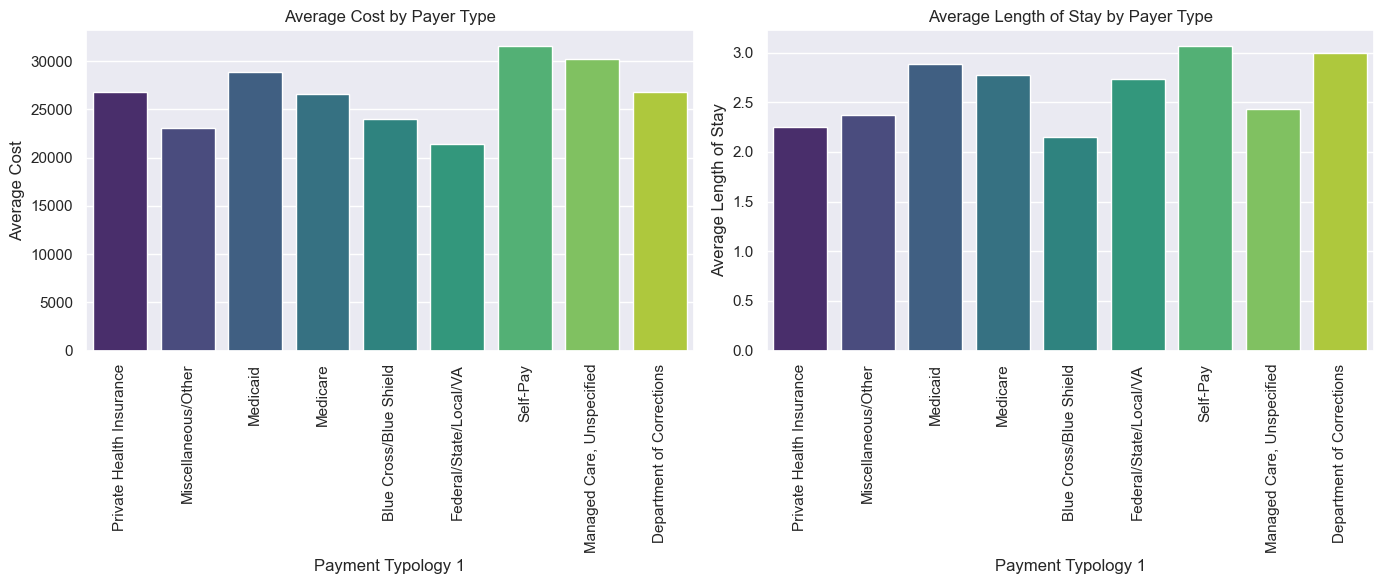

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x='Payment Typology 1', y='Total Costs', data=filtered_df, estimator='mean', ci=None, palette='viridis', ax=axes[0])
axes[0].set_title('Average Cost by Payer Type')
axes[0].set_ylabel('Average Cost')
axes[0].set_xlabel('Payment Typology 1')
axes[0].tick_params(axis='x', rotation=90)

sns.barplot(x='Payment Typology 1', y='Length of Stay', data=filtered_df, estimator='mean', ci=None, palette='viridis', ax=axes[1])
axes[1].set_title('Average Length of Stay by Payer Type')
axes[1].set_ylabel('Average Length of Stay')
axes[1].set_xlabel('Payment Typology 1')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Used Payer Type attribute instead of Payment Typology 1

In [58]:
cost_description = filtered_df.groupby('Payer Type')['Total Costs'].describe()
los_description = filtered_df.groupby('Payer Type')['Length of Stay'].describe()

print("Cost Description by Payer Type:")
print(cost_description)

print("\nLength of Stay Description by Payer Type:")
print(los_description)

Cost Description by Payer Type:
                        count          mean           std   min       25%  \
Payer Type                                                                  
Government Insurance  15149.0  26878.559428  17947.364960  80.0  15313.73   
Private Payers         7065.0  25443.153860  15617.444476  80.0  14501.63   

                           50%       75%        max  
Payer Type                                           
Government Insurance  23442.32  33186.35  673660.79  
Private Payers        21959.53  31629.11  388664.94  

Length of Stay Description by Payer Type:
                        count      mean       std  min  25%  50%  75%   max
Payer Type                                                                 
Government Insurance  15149.0  2.792330  3.093524  1.0  1.0  2.0  3.0  70.0
Private Payers         7065.0  2.247417  2.246600  1.0  1.0  2.0  3.0  60.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\236174333.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Payer Type', y='Total Costs', data=filtered_df, estimator='mean', ci=None, palette='viridis', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_2828\236174333.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Payer Type', y='Length of Stay', data=filtered_df, estimator='mean', ci=None, palette='viridis', ax=axes[1])


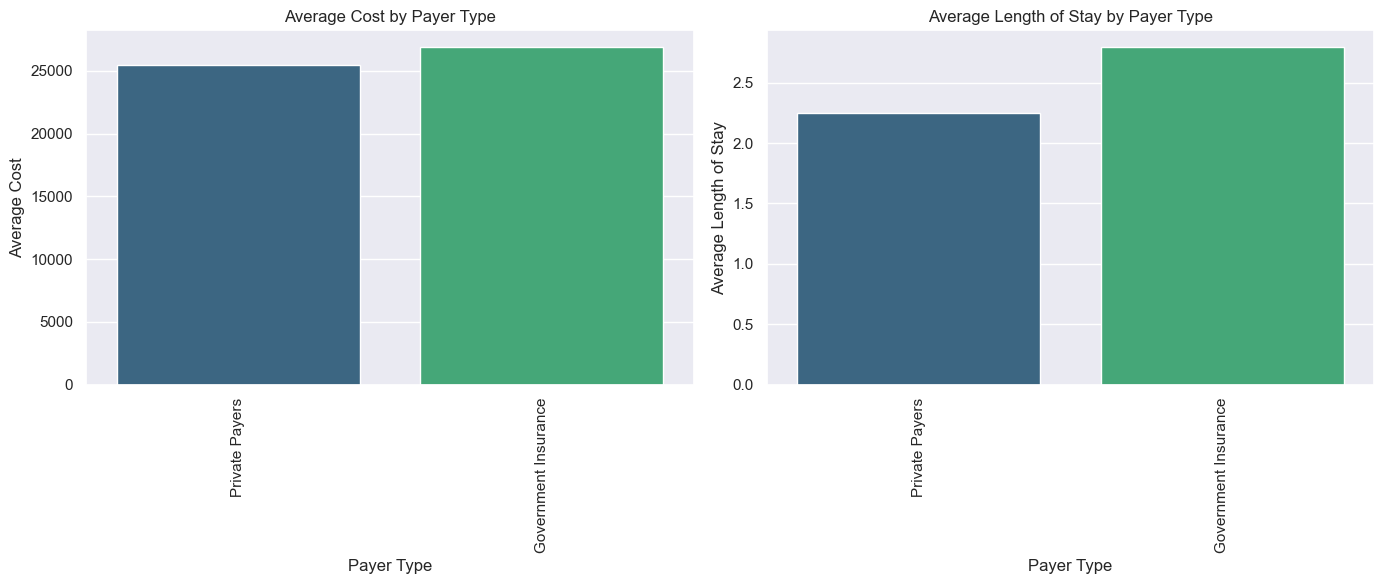

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x='Payer Type', y='Total Costs', data=filtered_df, estimator='mean', ci=None, palette='viridis', ax=axes[0])
axes[0].set_title('Average Cost by Payer Type')
axes[0].set_ylabel('Average Cost')
axes[0].set_xlabel('Payer Type')
axes[0].tick_params(axis='x', rotation=90)

sns.barplot(x='Payer Type', y='Length of Stay', data=filtered_df, estimator='mean', ci=None, palette='viridis', ax=axes[1])
axes[1].set_title('Average Length of Stay by Payer Type')
axes[1].set_ylabel('Average Length of Stay')
axes[1].set_xlabel('Payer Type')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## 2. What is the payer mix (distribution of all available payers), by Hospital service area?

In [60]:
payer_distribution = filtered_df.groupby(['Hospital Service Area', 'Payment Typology 1']).size().unstack(fill_value=0)
payer_distribution_percentage = payer_distribution.divide(payer_distribution.sum(axis=1), axis=0) * 100

print("Payer Distribution by Hospital Service Area:")
print(payer_distribution_percentage)

Payer Distribution by Hospital Service Area:
Payment Typology 1     Blue Cross/Blue Shield  Department of Corrections  \
Hospital Service Area                                                      
Capital/Adirond                     13.039014                   0.000000   
Central NY                          19.774011                   0.000000   
Finger Lakes                        18.088235                   0.000000   
Hudson Valley                        9.696970                   0.060606   
Long Island                         13.350021                   0.000000   
New York City                        9.147394                   0.000000   
Southern Tier                       18.750000                   0.000000   
Western NY                          10.854093                   0.355872   

Payment Typology 1     Federal/State/Local/VA  Managed Care, Unspecified  \
Hospital Service Area                                                      
Capital/Adirond                      0.718

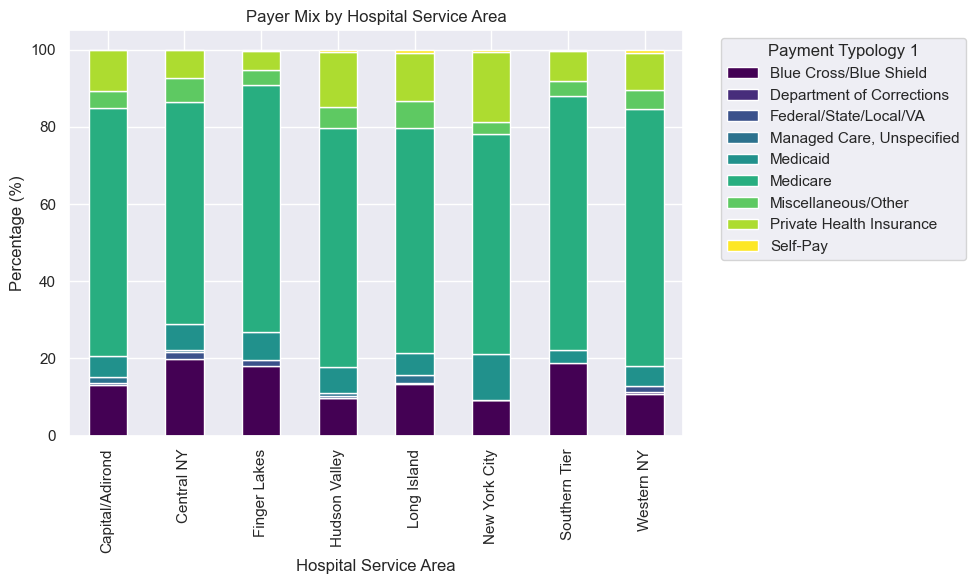

In [61]:
ax = payer_distribution_percentage.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
ax.set_title('Payer Mix by Hospital Service Area')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Hospital Service Area')
ax.legend(title='Payment Typology 1', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Used Payer Type attribute instead of Payment Typology 1

In [62]:
payer_distribution = filtered_df.groupby(['Hospital Service Area', 'Payer Type']).size().unstack(fill_value=0)
payer_distribution_percentage = payer_distribution.divide(payer_distribution.sum(axis=1), axis=0) * 100

print("Payer Distribution by Hospital Service Area:")
print(payer_distribution_percentage)

Payer Distribution by Hospital Service Area:
Payer Type             Government Insurance  Private Payers
Hospital Service Area                                      
Capital/Adirond                   70.431211       29.568789
Central NY                        66.195857       33.804143
Finger Lakes                      72.720588       27.279412
Hudson Valley                     69.272727       30.727273
Long Island                       64.142678       35.857322
New York City                     68.898861       31.101139
Southern Tier                     69.196429       30.803571
Western NY                        73.665480       26.334520


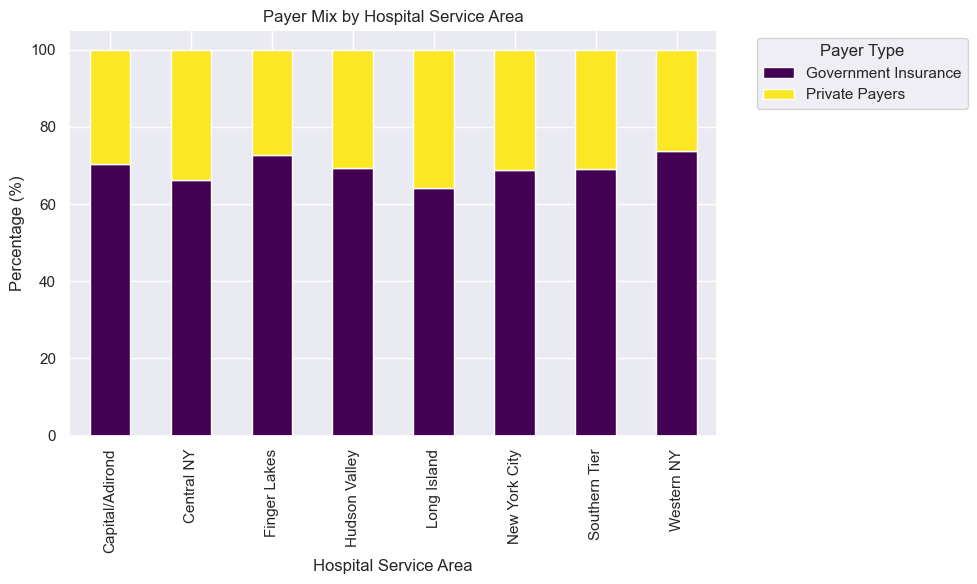

In [63]:
ax = payer_distribution_percentage.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
ax.set_title('Payer Mix by Hospital Service Area')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Hospital Service Area')
ax.legend(title='Payer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [64]:
filtered_df['Payer Type'] = filtered_df['Payer Type'].map({'Government Insurance': 0, 'Private Payers': 1})

In [65]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22214 entries, 458 to 2135222
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Hospital Service Area                22214 non-null  object 
 1   Hospital County                      22214 non-null  object 
 2   Facility Name                        22214 non-null  object 
 3   Age Group                            22214 non-null  object 
 4   Zip Code - 3 digits                  22214 non-null  object 
 5   Gender                               22214 non-null  object 
 6   Race                                 22214 non-null  object 
 7   Ethnicity                            22214 non-null  object 
 8   Length of Stay                       22214 non-null  float64
 9   Type of Admission                    22214 non-null  object 
 10  Patient Disposition                  22214 non-null  object 
 11  CCSR Diagnosis Description   

In [66]:
Cat_df = filtered_df.select_dtypes(include=["category","object"])
Cat_df.columns

Index(['Hospital Service Area', 'Hospital County', 'Facility Name',
       'Age Group', 'Zip Code - 3 digits', 'Gender', 'Race', 'Ethnicity',
       'Type of Admission', 'Patient Disposition',
       'CCSR Diagnosis Description', 'CCSR Procedure Description',
       'APR DRG Description', 'APR MDC Description',
       'APR Severity of Illness Description', 'APR Risk of Mortality',
       'APR Medical Surgical Description', 'Payment Typology 1',
       'Emergency Department Indicator'],
      dtype='object')

In [67]:
status = pd.get_dummies(filtered_df[Cat_df.columns])

In [68]:
status = pd.get_dummies(filtered_df[Cat_df.columns], drop_first = True)

In [69]:
status.columns

Index(['Hospital Service Area_Central NY',
       'Hospital Service Area_Finger Lakes',
       'Hospital Service Area_Hudson Valley',
       'Hospital Service Area_Long Island',
       'Hospital Service Area_New York City',
       'Hospital Service Area_Southern Tier',
       'Hospital Service Area_Western NY', 'Hospital County_Allegany',
       'Hospital County_Bronx', 'Hospital County_Broome',
       ...
       'APR Medical Surgical Description_Surgical',
       'Payment Typology 1_Department of Corrections',
       'Payment Typology 1_Federal/State/Local/VA',
       'Payment Typology 1_Managed Care, Unspecified',
       'Payment Typology 1_Medicaid', 'Payment Typology 1_Medicare',
       'Payment Typology 1_Miscellaneous/Other',
       'Payment Typology 1_Private Health Insurance',
       'Payment Typology 1_Self-Pay', 'Emergency Department Indicator_Y'],
      dtype='object', length=420)

In [70]:
filtered_df_new = filtered_df.drop(columns=Cat_df.columns)
filtered_df_new.shape

(22214, 4)

In [71]:
filtered_df_new.shape

(22214, 4)

In [72]:
filtered_df_new = pd.concat([filtered_df_new, status], axis = 1)

In [73]:
filtered_df_new.shape

(22214, 424)

In [74]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [75]:
Num_df = filtered_df_new.select_dtypes(include=["int64","float64"])
Num_df.columns

Index(['Length of Stay', 'Total Charges', 'Total Costs', 'Payer Type'], dtype='object')

In [76]:
filtered_df_new[Num_df.columns] = scaler.fit_transform(filtered_df_new[Num_df.columns])

In [77]:
filtered_df_new.shape

(22214, 424)

### 3. What are the factors that influence cost? How about LOS? Are the factors similar? Why and why not?

### Feature Importnace of Total Costs

In [78]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = filtered_df_new.drop(['Total Costs'], axis=1)
y = filtered_df_new['Total Costs']

X = sm.add_constant(X)

model_costs = sm.OLS(y, X.astype(float)).fit()

print("OLS Regression Summary:")
print(model_costs.summary())

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:            Total Costs   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     589.6
Date:                Thu, 25 Jul 2024   Prob (F-statistic):               0.00
Time:                        12:47:58   Log-Likelihood:                 75909.
No. Observations:               22214   AIC:                        -1.511e+05
Df Residuals:                   21864   BIC:                        -1.483e+05
Df Model:                         349                                         
Covariance Type:            nonrobust                                         
                                                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------

In [79]:
importances = model_costs.params[1:]
importances_df = pd.DataFrame({'Importance': importances}).sort_values(by='Importance', ascending=False)

importances_df.head(10)

,Importance
Total Charges,0.577749
APR DRG Description_TRACHEOSTOMY WITH MV >96 HOURS WITH EXTENSIVE PROCEDURE,0.224051
Length of Stay,0.125754
"CCSR Diagnosis Description_Superficial injury; contusion, initial encounter",0.096597
CCSR Diagnosis Description_Skin and subcutaneous tissue infections,0.084264
Facility Name_Harlem Hospital Center,0.077023
CCSR Diagnosis Description_Fever,0.057057
CCSR Diagnosis Description_Septicemia,0.054703
"Facility Name_New York Community Hospital of Brooklyn, Inc",0.050165
APR MDC Description_INFECTIOUS AND PARASITIC DISEASES (SYSTEMIC OR UNSPECIFIED SITES),0.048926


###  Cross Validation of Total Costs

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_costs_val = sm.OLS(y_train, X_train.astype(float)).fit()

print("OLS Regression Summary:")
print(model_costs_val.summary())

y_pred = model_costs_val.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:            Total Costs   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     509.5
Date:                Thu, 25 Jul 2024   Prob (F-statistic):               0.00
Time:                        12:47:59   Log-Likelihood:                 61099.
No. Observations:               17771   AIC:                        -1.215e+05
Df Residuals:                   17426   BIC:                        -1.188e+05
Df Model:                         344                                         
Covariance Type:            nonrobust                                         
                                                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------

Mean Squared Error: 7.736313936906185e-05
R^2 Score: 0.8726838271021431


In [81]:
importances = model_costs_val.params[1:] 
importances_df = pd.DataFrame({'Importance': importances}).sort_values(by='Importance', ascending=False)

importances_df.head(10)

,Importance
Total Charges,0.586188
APR DRG Description_TRACHEOSTOMY WITH MV >96 HOURS WITH EXTENSIVE PROCEDURE,0.220222
Length of Stay,0.126627
"CCSR Diagnosis Description_Superficial injury; contusion, initial encounter",0.096198
CCSR Diagnosis Description_Skin and subcutaneous tissue infections,0.082824
Facility Name_Harlem Hospital Center,0.076525
CCSR Diagnosis Description_Fever,0.057290
"Facility Name_New York Community Hospital of Brooklyn, Inc",0.055802
CCSR Diagnosis Description_Septicemia,0.051844
APR MDC Description_INFECTIOUS AND PARASITIC DISEASES (SYSTEMIC OR UNSPECIFIED SITES),0.048217


### Feature Importnace of Length of Stay

In [82]:

X = filtered_df_new.drop(['Length of Stay'], axis=1)
y = filtered_df_new['Length of Stay']

X = sm.add_constant(X)

model_los = sm.OLS(y, X.astype(float)).fit()

print("OLS Regression Summary:")
print(model_los.summary())

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:         Length of Stay   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     143.7
Date:                Thu, 25 Jul 2024   Prob (F-statistic):               0.00
Time:                        12:48:00   Log-Likelihood:                 52410.
No. Observations:               22214   AIC:                        -1.041e+05
Df Residuals:                   21864   BIC:                        -1.013e+05
Df Model:                         349                                         
Covariance Type:            nonrobust                                         
                                                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------

In [83]:
importances = model_los.params[1:]  # Exclude the constant term
importances_df = pd.DataFrame({'Importance': importances}).sort_values(by='Importance', ascending=False)

importances_df.head(10)

,Importance
Total Costs,1.043138
CCSR Diagnosis Description_Crystal arthropathies (excluding gout),0.223157
APR DRG Description_INFECTIOUS AND PARASITIC DISEASES INCLUDING HIV WITH O.R. PROCEDURE,0.214281
CCSR Diagnosis Description_COVID-19,0.200427
CCSR Diagnosis Description_Heart failure,0.136217
Total Charges,0.124024
"CCSR Diagnosis Description_Traumatic brain injury (TBI); concussion, initial encounter",0.106007
"APR DRG Description_POST-OPERATIVE, POST-TRAUMA, OTHER DEVICE INFECTIONS WITH O.R. PROCEDURE",0.095052
CCSR Diagnosis Description_Postprocedural or postoperative circulatory system complication,0.074813
CCSR Diagnosis Description_Myocarditis and cardiomyopathy,0.072626


### Cross Validation of Length of Stay

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_los_val = sm.OLS(y_train, X_train.astype(float)).fit()

print("OLS Regression Summary:")
print(model_los_val.summary())

y_pred = model_los_val.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:         Length of Stay   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     122.7
Date:                Thu, 25 Jul 2024   Prob (F-statistic):               0.00
Time:                        12:48:01   Log-Likelihood:                 42603.
No. Observations:               17771   AIC:                        -8.452e+04
Df Residuals:                   17426   BIC:                        -8.183e+04
Df Model:                         344                                         
Covariance Type:            nonrobust                                         
                                                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------

Mean Squared Error: 0.0007428510121870612
R^2 Score: 0.6238645527009217


In [85]:
importances = model_los_val.params[1:]
importances_df = pd.DataFrame( {'Importance': importances}).sort_values(by='Importance', ascending=False)

importances_df.head(10)

,Importance
Total Costs,1.015184
APR DRG Description_INFECTIOUS AND PARASITIC DISEASES INCLUDING HIV WITH O.R. PROCEDURE,0.205985
CCSR Diagnosis Description_COVID-19,0.193906
CCSR Diagnosis Description_Heart failure,0.161657
Total Charges,0.128501
"APR DRG Description_POST-OPERATIVE, POST-TRAUMA, OTHER DEVICE INFECTIONS WITH O.R. PROCEDURE",0.103829
CCSR Diagnosis Description_Osteoporosis,0.080443
Facility Name_SJRH - St Johns Division,0.074721
CCSR Diagnosis Description_Myocarditis and cardiomyopathy,0.065910
"CCSR Diagnosis Description_Traumatic brain injury (TBI); concussion, initial encounter",0.064516


### Feature Importnace for Total Charges

In [86]:
X = filtered_df_new.drop(['Total Charges'], axis=1)
y = filtered_df_new['Total Charges']

X = sm.add_constant(X)

model_charges = sm.OLS(y, X.astype(float)).fit()

print("OLS Regression Summary:")
print(model_charges.summary())

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:          Total Charges   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     615.8
Date:                Thu, 25 Jul 2024   Prob (F-statistic):               0.00
Time:                        12:48:02   Log-Likelihood:                 69670.
No. Observations:               22214   AIC:                        -1.386e+05
Df Residuals:                   21864   BIC:                        -1.358e+05
Df Model:                         349                                         
Covariance Type:            nonrobust                                         
                                                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------

In [87]:
importances = model_charges.params[1:]
importances_df = pd.DataFrame({'Importance': importances}).sort_values(by='Importance', ascending=False)

importances_df.head(10)

,Importance
Total Costs,1.013152
"APR MDC Description_DISEASES AND DISORDERS OF THE SKIN, SUBCUTANEOUS TISSUE AND BREAST",0.103230
Facility Name_Montefiore Medical Center - Henry & Lucy Moses Div,0.076586
Type of Admission_Trauma,0.072140
Facility Name_NYU Langone Hospital-Brooklyn,0.060171
Facility Name_NYU Langone Hospital-Long Island,0.057992
Facility Name_NYU Langone Orthopedic Hospital,0.053730
Facility Name_NYU Langone Hospitals,0.052413
APR DRG Description_MODERATELY EXTENSIVE O.R. PROCEDURE UNRELATED TO PRINCIPAL DIAGNOSIS,0.045174
Facility Name_Mount Sinai Brooklyn,0.042108


In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_charges_val = sm.OLS(y_train, X_train.astype(float)).fit()

print("OLS Regression Summary:")
print(model_charges_val.summary())

y_pred = model_charges_val.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:          Total Charges   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     531.9
Date:                Thu, 25 Jul 2024   Prob (F-statistic):               0.00
Time:                        12:48:03   Log-Likelihood:                 56319.
No. Observations:               17771   AIC:                        -1.119e+05
Df Residuals:                   17426   BIC:                        -1.093e+05
Df Model:                         344                                         
Covariance Type:            nonrobust                                         
                                                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------

Mean Squared Error: 0.0001458052312272035
R^2 Score: 0.8808456842159075


### 4. We have a hypothesis that patients with government insurance has higher cost compared to those private payers. How do you test this hypothesis statistically?

In [89]:
from scipy.stats import ttest_ind

gov_costs = filtered_df[filtered_df['Payer Type'] == 0]['Total Costs']
private_costs = filtered_df[filtered_df['Payer Type'] == 1]['Total Costs']

t_stat, p_value = ttest_ind(gov_costs, private_costs)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: Government insurance patients have different costs.")
else:
    print("Fail to reject the null hypothesis: No significant difference in costs.")

T-statistic: 5.779067058247425
P-value: 7.612045444860847e-09
Reject the null hypothesis: Government insurance patients have different costs.
